# Routing Analysis — where does biology knowledge live?

Loads the per-dataset routing JSONs (`run_results/routing_single/<model>/<tag>.json`) and visualizes:
1. **Concentration** per layer — how many experts each domain effectively uses.
2. **Divergence** per layer — how differently biology routes vs. benign biology and vs. science (total-variation distance).
3. **Overlap** per layer — fraction of top experts shared.
4. **Biology-specific experts** — heatmap of `freq(bio) - freq(science)` over layers x experts.

These tell you **which layers** biology is most localized / most distinct in — the candidate layers for unlearning.

> Caveat: with 160 prompts there is sampling noise. Treat single-layer rankings as suggestive until a noise floor is established (split one dataset in half and compare).

In [15]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Navigate to project root from notebook location
RESULTS = Path('.').resolve().parent / 'run_results/routing_single/Qwen3-30B-A3B'
TAGS = ['wmdp_bio', 'mmlu_college_biology', 'general_mmlu_science']
LABELS = {'wmdp_bio':'hazardous bio', 'mmlu_college_biology':'benign bio', 'general_mmlu_science':'science'}

data = {t: json.load(open(RESULTS / f'{t}.json')) for t in TAGS}
freq = {t: np.array(d['freq']) for t, d in data.items()}        # [layers, experts]
n_layers  = data[TAGS[0]]['num_layers']
n_experts = data[TAGS[0]]['num_experts']
top_k     = data[TAGS[0]]['top_k']
print(f'layers={n_layers}  experts={n_experts}  top_k={top_k}')
for t in TAGS:
    print(f"  {t}: {data[t]['n_prompts']} prompts")

layers=48  experts=128  top_k=8
  wmdp_bio: 160 prompts
  mmlu_college_biology: 160 prompts
  general_mmlu_science: 160 prompts


## 1. Concentration — effective number of experts per layer
`exp(H(freq))` = how many experts a domain effectively uses at each layer. Lower = more concentrated (knowledge localized). 128 = perfectly spread.

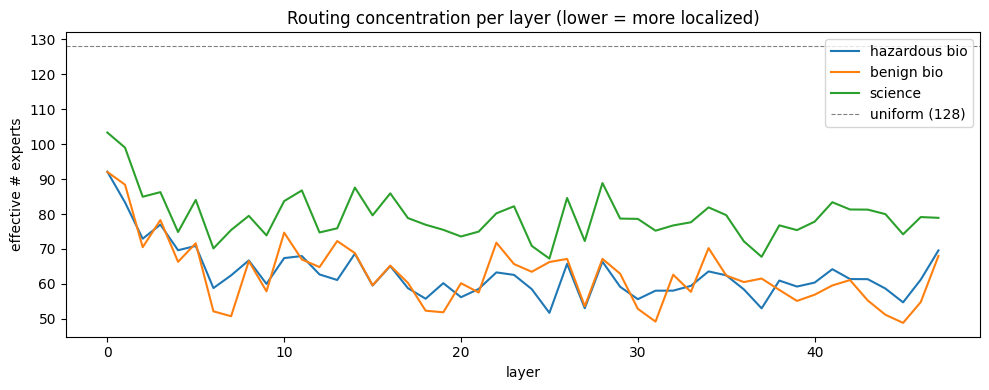

In [16]:
def eff_experts(f):
    H = -(f * np.log(f + 1e-12)).sum(axis=1)   # entropy of usage per layer
    return np.exp(H)

plt.figure(figsize=(10,4))
for t in TAGS:
    plt.plot(eff_experts(freq[t]), label=LABELS[t])
plt.axhline(n_experts, ls='--', c='grey', lw=0.8, label='uniform (128)')
plt.xlabel('layer'); plt.ylabel('effective # experts'); plt.legend()
plt.title('Routing concentration per layer (lower = more localized)')
plt.tight_layout(); plt.show()

## 2. Divergence — where does biology route *differently*?
Total-variation distance per layer: `0.5 * sum|freq_A - freq_B|`. 0 = identical routing, 1 = completely different.
**Peaks = layers where biology uses a distinct expert mix** → candidate layers to intervene.

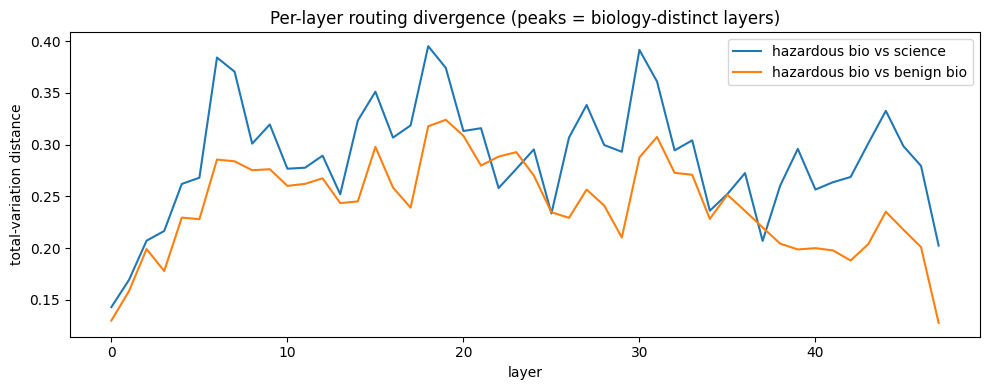

Top-5 layers where hazardous bio diverges MOST from science: [18, 30, 6, 19, 7]
Mean TV  bio-science: 0.288  bio-benignbio: 0.242


In [11]:
tv = lambda a, b: 0.5 * np.abs(a - b).sum(axis=1)
tv_bio_sci = tv(freq['wmdp_bio'], freq['general_mmlu_science'])
tv_bio_ben = tv(freq['wmdp_bio'], freq['mmlu_college_biology'])

plt.figure(figsize=(10,4))
plt.plot(tv_bio_sci, label='hazardous bio vs science')
plt.plot(tv_bio_ben, label='hazardous bio vs benign bio')
plt.xlabel('layer'); plt.ylabel('total-variation distance'); plt.legend()
plt.title('Per-layer routing divergence (peaks = biology-distinct layers)')
plt.tight_layout(); plt.show()

print('Top-5 layers where hazardous bio diverges MOST from science:',
      np.argsort(tv_bio_sci)[::-1][:5].tolist())
print('Mean TV  bio-science:', round(tv_bio_sci.mean(),3),
      ' bio-benignbio:', round(tv_bio_ben.mean(),3))

## 3. Top-expert overlap per layer
Fraction of the top-`K` experts shared between two domains. High = shared experts (collateral risk if unlearned).

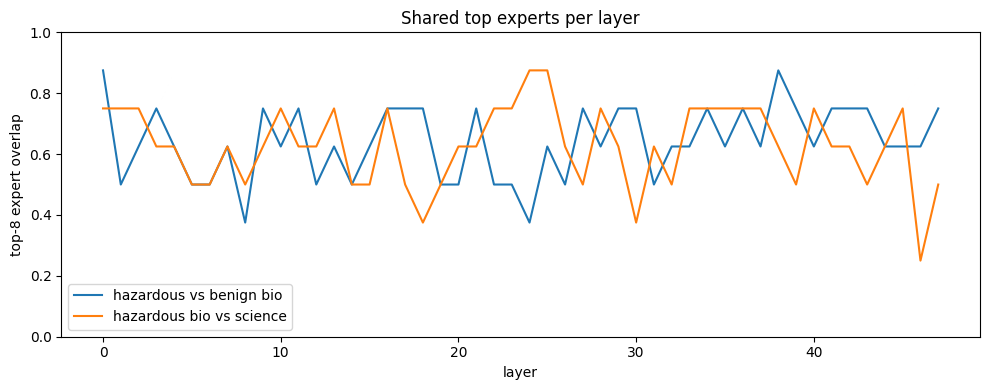

In [12]:
K = top_k  # compare the top-k most-used experts (matches routing top_k)
def topk_sets(f, k): return [set(np.argsort(f[l])[::-1][:k]) for l in range(f.shape[0])]
def overlap(a, b, k):
    A, B = topk_sets(a, k), topk_sets(b, k)
    return np.array([len(A[l] & B[l]) / k for l in range(len(A))])

ov_bio_ben = overlap(freq['wmdp_bio'], freq['mmlu_college_biology'], K)
ov_bio_sci = overlap(freq['wmdp_bio'], freq['general_mmlu_science'], K)
plt.figure(figsize=(10,4))
plt.plot(ov_bio_ben, label='hazardous vs benign bio')
plt.plot(ov_bio_sci, label='hazardous bio vs science')
plt.xlabel('layer'); plt.ylabel(f'top-{K} expert overlap'); plt.ylim(0,1); plt.legend()
plt.title('Shared top experts per layer')
plt.tight_layout(); plt.show()

## 4. Biology-specific experts — heatmap
`freq(hazardous bio) - freq(science)` over layers x experts. Red = experts biology uses *more* than science; blue = less. Bright vertical streaks = consistently biology-preferred experts.

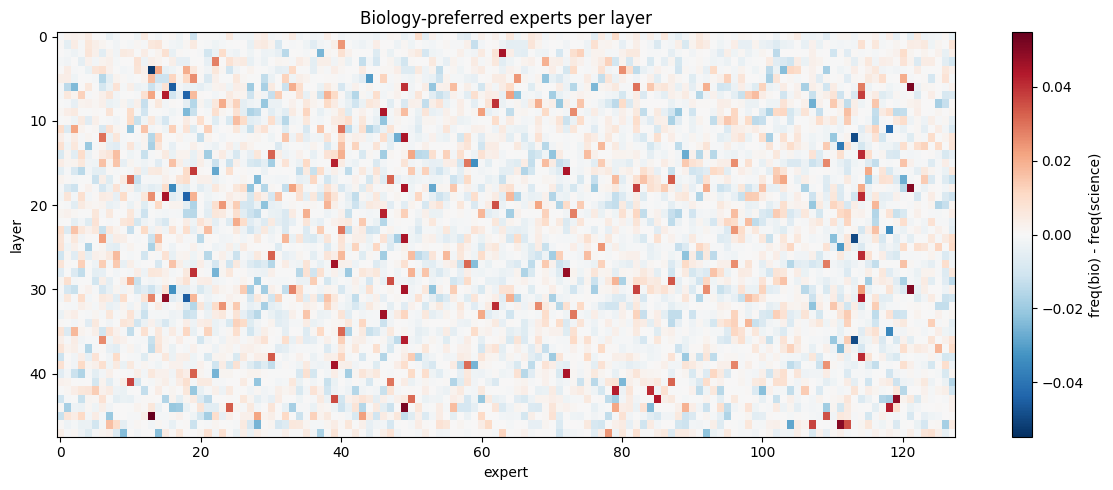

Most biology-preferred (layer, expert, delta):
  layer 45  expert  13  +0.055
  layer 44  expert  49  +0.051
  layer  6  expert 121  +0.051
  layer 30  expert 121  +0.051
  layer 18  expert 121  +0.050
  layer 46  expert 111  +0.050
  layer 43  expert 119  +0.049
  layer 31  expert  15  +0.048
  layer 28  expert  72  +0.048
  layer 33  expert  46  +0.046


In [13]:
diff = freq['wmdp_bio'] - freq['general_mmlu_science']   # [layers, experts]
vmax = np.abs(diff).max()
plt.figure(figsize=(12,5))
plt.imshow(diff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='freq(bio) - freq(science)')
plt.xlabel('expert'); plt.ylabel('layer')
plt.title('Biology-preferred experts per layer')
plt.tight_layout(); plt.show()

# the most biology-specific (expert, layer) cells
flat = np.argsort(diff.ravel())[::-1][:10]
print('Most biology-preferred (layer, expert, delta):')
for idx in flat:
    l, e = divmod(idx, n_experts)
    print(f'  layer {l:2d}  expert {e:3d}  +{diff[l,e]:.3f}')

## 5. Candidate layers for unlearning
Heuristic score combining **distinctness** (bio diverges from science) and **concentration** (bio uses fewer experts). Higher = better unlearning target: biology is localized *and* distinguishable there.

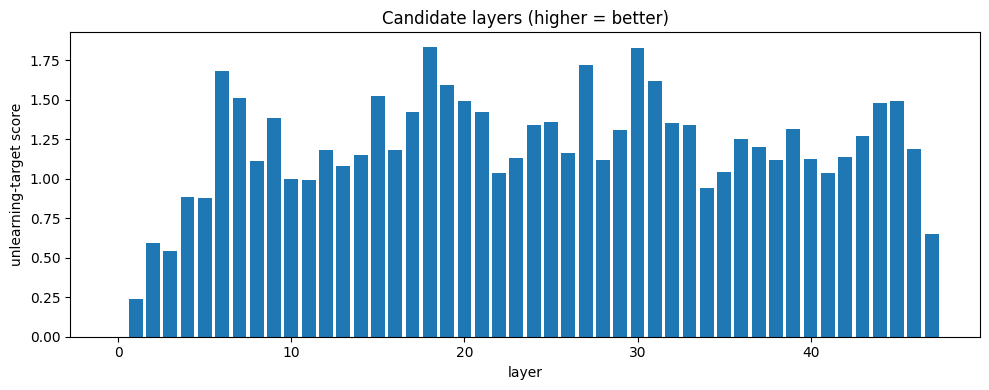

Top candidate layers: [18, 30, 27, 6, 31, 19]


In [14]:
distinct = tv_bio_sci                                   # higher = more biology-specific routing
concentration = 1.0 / eff_experts(freq['wmdp_bio'])     # higher = fewer experts used
# normalise each to [0,1] and combine
norm = lambda x: (x - x.min()) / (x.ptp() + 1e-9)
score = norm(distinct) + norm(concentration)

plt.figure(figsize=(10,4))
plt.bar(range(n_layers), score)
plt.xlabel('layer'); plt.ylabel('unlearning-target score'); plt.title('Candidate layers (higher = better)')
plt.tight_layout(); plt.show()
print('Top candidate layers:', np.argsort(score)[::-1][:6].tolist())